In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df_test_signal = pd.read_parquet("df_test_signal.parquet")

In [2]:
df_test_signal

,SecuCode,TradingDay,TimeStart,TimeEnd,mid,spread,log_mid_ret_t1,ret_mid_t1,f_001,f_002,...,f_062,f_063,f_064,f_065,f_066,f_067,f_068,f_069,f_070,signal_boost
0,400,20231205,930,945,19.888906,0.019319,-0.004137,-0.004128,-0.000030,0.510791,...,0.000596,-0.001854,0.820900,0.001215,0.076228,-5865319.00,0.335301,-1.448781,1.250049,0.000036
1,400,20231205,945,1000,19.806800,0.009659,0.001705,0.001707,0.002476,0.493056,...,0.000071,-0.005292,1.528358,-0.000975,-0.061169,-4272295.50,-0.568664,-1.474823,-0.257768,-0.000050
2,400,20231205,1000,1015,19.840609,0.019319,-0.003170,-0.003165,0.002993,0.510067,...,-0.000151,-0.001077,1.258934,0.001218,0.074166,-799507.44,0.476824,-2.061131,0.561447,-0.000034
3,400,20231205,1015,1030,19.777822,0.009659,-0.000489,-0.000488,0.004363,0.490323,...,-0.000209,0.009778,1.786533,-0.000976,-0.059457,-4997067.00,0.496168,-2.179297,-0.268834,-0.000157
4,400,20231205,1030,1045,19.768162,0.009659,-0.000489,-0.000489,0.005087,0.292035,...,-0.000128,0.040171,1.746370,-0.022229,-1.353654,2004316.40,-0.553447,-2.782563,-0.414473,-0.000255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402753,603000,20251231,1330,1345,19.095000,0.010000,-0.001048,-0.001047,-0.004426,0.689657,...,-0.000375,0.000482,-1.107431,0.011588,1.053472,5556700.00,-0.556397,0.266175,-0.520702,0.000007
402754,603000,20251231,1345,1400,19.075000,0.010000,0.000524,0.000524,-0.003679,0.636365,...,-0.000195,-0.010359,-0.826147,0.007895,0.717714,11147642.00,1.332818,0.211717,-0.230000,-0.000140
402755,603000,20251231,1400,1415,19.085000,0.010000,-0.000524,-0.000524,-0.003449,0.711540,...,0.000007,-0.005849,-0.835640,0.010800,1.028526,16346551.00,0.036089,0.217472,0.277991,-0.000009
402756,603000,20251231,1415,1430,19.075000,0.010000,0.000000,0.000000,-0.002876,0.666668,...,0.000134,-0.001110,-0.660246,0.008952,0.852585,17050074.00,-0.153014,0.151432,-0.367844,-0.000068


In [3]:
import numpy as np
import pandas as pd

# 提取每天收盘那一根 bar（14:45 - 15:00），并构建回测用的 price / spread / signal 矩阵，同时判断哪些股票在 t 和 t+1 都能交易（eligible）
def prepare_close_bar_data(
    df, # 数据集，必须包括这些列：TradingDay, SecuCode, TimeStart, TimeEnd, signal_pred, mid, spread
    signal_col, # 预测信号列名称
    price_col, # 价格列名称
    spread_col, # spread 列名称
    day_col, # 交易日列名称
    stock_col, # 股票代码列名称
    close_ts, # 交易时段开始时间 (hh:ss => hhss)
    close_te, # 交易时段结束时间
):

    df = df.copy()
    df = df.sort_values([day_col, "TimeStart", "TimeEnd", stock_col]).reset_index(drop=True)

    needed_cols = [day_col, stock_col, "TimeStart", "TimeEnd", signal_col, price_col, spread_col]
    miss = [c for c in needed_cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns in input df: {miss}")

    df_close = df[
        (df["TimeStart"] == close_ts) & (df["TimeEnd"] == close_te)
    ][[day_col, stock_col, signal_col, price_col, spread_col]].copy()

    df_close = df_close.sort_values([stock_col, day_col]).reset_index(drop=True)

    df_close["has_price_t"] = np.isfinite(df_close[price_col].astype(float))
    df_close["has_spread_t"] = np.isfinite(df_close[spread_col].astype(float))

    df_close["price_t1"] = df_close.groupby(stock_col)[price_col].shift(-1)
    df_close["spread_t1"] = df_close.groupby(stock_col)[spread_col].shift(-1)
    df_close["day_t1"] = df_close.groupby(stock_col)[day_col].shift(-1)

    all_days = np.sort(df_close[day_col].unique())
    next_day_map = pd.Series(all_days[1:], index=all_days[:-1]).to_dict()
    df_close["expected_day_t1"] = df_close[day_col].map(next_day_map)

    is_true_next_day = df_close["day_t1"].eq(df_close["expected_day_t1"])

    df_close["has_price_t1"] = is_true_next_day & np.isfinite(df_close["price_t1"].astype(float))
    df_close["has_spread_t1"] = is_true_next_day & np.isfinite(df_close["spread_t1"].astype(float))

    df_close["eligible"] = (  # 判断是否可交易
        df_close[signal_col].notna()
        & df_close["has_price_t"]
        & df_close["has_spread_t"]
        & df_close["has_price_t1"]
        & df_close["has_spread_t1"]
    )

    days = np.sort(df_close[day_col].unique())
    stocks = np.sort(df_close[stock_col].unique())

    price_mat = (
        df_close.pivot(index=day_col, columns=stock_col, values=price_col)
        .reindex(index=days, columns=stocks)
        .astype("float64")
    )
    price_mat.index.name = day_col
    price_mat.columns.name = stock_col

    spread_mat = (
        df_close.pivot(index=day_col, columns=stock_col, values=spread_col)
        .reindex(index=days, columns=stocks)
        .astype("float64")
    )
    spread_mat.index.name = day_col
    spread_mat.columns.name = stock_col

    signal_mat = (
        df_close.pivot(index=day_col, columns=stock_col, values=signal_col)
        .reindex(index=days, columns=stocks)
        .astype("float64")
    )
    signal_mat.index.name = day_col
    signal_mat.columns.name = stock_col

    eligible_mat = (
        df_close.pivot(index=day_col, columns=stock_col, values="eligible")
        .reindex(index=days, columns=stocks)
        .fillna(False)
        .astype(bool)
    )
    eligible_mat.index.name = day_col
    eligible_mat.columns.name = stock_col

    return {
        "df_close": df_close, # 保留原来的TradingDay, SecuCode, signal_pred, mid, spread列，外加上新的列：
        # has_price_t : 当天价格是否存在且有效
        # has_spread_t : 当天spread是否存在且有效
        # price_t1 : 下一天的价格
        # spread_t1 : 下一天的 spread
        # has_price_t1 : 下一天的价格是否存在且有效
        # has_spread_t1 : 下一天的 spread 是否存在且有效
        # day_t1 : 下一天的日期
        # expected_day_t1 : 理论上下一天的日期
        # eligible : 是否可交易 
        "price_mat": price_mat, # 每只股票在每个交易日的价格，行名为交易日，列名为股票代码
        "spread_mat": spread_mat, # 每只股票在每个交易日的spread，行名为交易日，列名为股票代码
        "signal_mat": signal_mat, # 每只股票在每个交易日的信号，行名为交易日，列名为股票代码
        "eligible_mat": eligible_mat,# 每只股票在每个交易日是否可交易，行名为交易日，列名为股票代码
    }

# 每天选出 signal 最大的 top K 只股票，并给它们等权重，其它全为 0
def transform_signal_to_weight_topk(signal_mat, eligible_mat, top_k):
    idx = signal_mat.index.intersection(eligible_mat.index)
    cols = signal_mat.columns.intersection(eligible_mat.columns)

    signal_mat = signal_mat.loc[idx, cols].copy()
    eligible_mat = eligible_mat.loc[idx, cols].copy()

    signal_used_mat = signal_mat.where(eligible_mat, np.nan)
    rank_mat = signal_used_mat.rank(axis=1, method="first", ascending=False)
    selected_mat = (rank_mat <= top_k)

    n_selected = selected_mat.sum(axis=1)
    target_w_mat = selected_mat.div(n_selected.replace(0, np.nan), axis=0).fillna(0.0)

    target_w_mat = target_w_mat.astype("float64")
    signal_used_mat = signal_used_mat.astype("float64")
    rank_mat = rank_mat.astype("float64")
    selected_mat = selected_mat.astype("int8")

    return {
        "target_w_mat": target_w_mat, # 每只股票在每个交易日被分配的权重，行名为交易日，列名为股票代码
        "signal_used_mat": signal_used_mat, # 经过eligible过滤后的信号矩阵（可用的信号），行名为交易日，列名为股票代码
        "rank_mat": rank_mat, # 每只股票在每个交易日的排名（根据信号排的），行名为交易日，列名为股票代码
        "selected_mat": selected_mat,# 每只股票在每个交易日是否被选进了 top-K 里，行名为交易日，列名为股票代码
    }

In [5]:
prep = prepare_close_bar_data(
    df=df_test_signal,
    signal_col="signal_boost",
    price_col="mid",
    spread_col="spread",
    day_col="TradingDay",
    stock_col="SecuCode",
    close_ts=1445,
    close_te=1500,
)

C:\Users\16473\AppData\Local\Temp\ipykernel_9256\3616089742.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [6]:
prep["price_mat"]

SecuCode,400,415,423,425,503,559,581,629,738,778,...,601169,601231,601328,601555,601718,601818,601857,601933,601988,603000
TradingDay,,,,,,,,,,,,,,,,,,,,,
20231205,19.589462,2.215,46.328663,5.079502,14.295,5.113524,14.208479,3.345,19.754097,3.837109,...,4.083121,13.843058,5.112216,6.990536,2.850791,2.615003,6.361318,3.005,3.584556,32.507286
20231206,19.497696,2.205,45.879270,5.050885,14.265,5.104063,14.150630,3.365,19.685318,3.817556,...,4.038103,13.785035,5.059102,6.962923,2.880435,2.596875,6.136218,3.015,3.530988,32.064070
20231207,19.444569,2.235,45.561512,5.060424,13.985,5.075681,13.985985,3.355,19.439682,3.768676,...,4.083121,13.988112,5.067954,7.036556,2.919961,2.605939,6.118210,2.995,3.566700,33.137634
20231208,19.608782,2.215,45.461647,5.108119,14.045,5.085142,13.816889,3.345,18.781376,3.719796,...,4.078619,14.191189,5.059102,7.008944,2.929842,2.624067,6.190242,2.935,3.504205,32.566383
20231211,20.270456,2.225,45.833874,5.050885,14.245,5.179749,13.834688,3.365,19.125267,3.700244,...,4.065114,14.413606,5.067954,7.165414,2.919961,2.615003,6.181238,2.965,3.495277,32.940650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20251224,26.565000,4.075,49.060000,10.845000,9.165,12.225000,20.335000,3.055,20.425000,4.125000,...,5.505000,30.550000,7.214674,9.075000,3.375000,3.505000,9.835000,5.455,5.665000,18.745000
20251225,26.665000,4.085,48.955000,10.705000,9.165,13.440000,20.485000,3.055,21.235000,4.145000,...,5.515000,30.525000,7.195000,9.075000,3.405000,3.515000,9.805000,5.275,5.645000,18.835000
20251226,26.425000,4.085,49.365000,11.225000,9.095,13.625000,20.545000,3.125,20.975000,4.185000,...,5.495000,29.835000,7.225000,9.175000,3.405000,3.505000,9.845000,5.285,5.605000,18.875000


In [7]:
# 按照你给的 target 权重，每天在收盘价交易，并计算整个组合的收益、成本、换手率和资金曲线
def run_close_to_close_backtest_from_weight(
    price_mat: pd.DataFrame,
    spread_mat: pd.DataFrame,
    target_w_mat: pd.DataFrame,
    signal_used_mat: pd.DataFrame | None = None,
    day_col: str = "TradingDay",
    stock_col: str = "SecuCode",
    init_cash: float = 1_000_000.0, # 起始资金
    fee_rate: float = 0.0003, # 每交易1块钱需要付多少手续费
    lot_size=None,# 最小交易单位
):
    """
    给定目标权重做 close-to-close 回测。
    口径：
    - t 日 close 执行
    - 持有到 t+1 日 close
    - 买入按 ask = mid + spread/2
    - 卖出按 bid = mid - spread/2
    """
    idx = price_mat.index.intersection(spread_mat.index).intersection(target_w_mat.index)
    cols = price_mat.columns.intersection(spread_mat.columns).intersection(target_w_mat.columns)

    price_mat = price_mat.loc[idx, cols].copy()
    spread_mat = spread_mat.loc[idx, cols].copy()
    target_w_mat = target_w_mat.loc[idx, cols].fillna(0.0).copy()

    if signal_used_mat is None:
        signal_used_mat = pd.DataFrame(np.nan, index=idx, columns=cols)
    else:
        signal_used_mat = signal_used_mat.loc[idx, cols].copy()

    signal_used_mat.index.name = day_col
    signal_used_mat.columns.name = stock_col

    days = price_mat.index.to_numpy()
    stocks = price_mat.columns.to_numpy()

    wsum = target_w_mat.sum(axis=1).values
    if np.any(wsum > 1.0 + 1e-6):
        bad = days[wsum > 1.0 + 1e-6][:10]
        raise ValueError(f"Target weights exceed 1 on some days, e.g. {bad}")

    P = price_mat.to_numpy(dtype=np.float64)
    S = spread_mat.to_numpy(dtype=np.float64)
    W = target_w_mat.to_numpy(dtype=np.float64)

    T, N = P.shape

    shares = np.zeros(N, dtype=np.float64)
    cash = float(init_cash)

    nav_pre = np.zeros(T, dtype=np.float64)
    nav_post = np.zeros(T, dtype=np.float64)
    cash_arr = np.zeros(T, dtype=np.float64)
    fee_arr = np.zeros(T, dtype=np.float64)
    spread_cost_arr = np.zeros(T, dtype=np.float64)
    turnover_arr = np.zeros(T, dtype=np.float64)
    shares_hist = np.zeros((T, N), dtype=np.float64)

    for t in range(T):
        p_mid_raw = P[t].copy()
        spr_raw = S[t].copy()
        w_tgt_raw = W[t].copy()

        need_price_mask = (shares > 1e-12) | (w_tgt_raw > 1e-12)

        if np.any(np.isnan(p_mid_raw[need_price_mask])):
            bad_idx = np.where(np.isnan(p_mid_raw) & need_price_mask)[0]
            bad_codes = stocks[bad_idx[:10]]
            raise ValueError(f"Missing price on day {days[t]} for required stocks, e.g. {bad_codes}")

        if np.any(np.isnan(spr_raw[need_price_mask])):
            bad_idx = np.where(np.isnan(spr_raw) & need_price_mask)[0]
            bad_codes = stocks[bad_idx[:10]]
            raise ValueError(f"Missing spread on day {days[t]} for required stocks, e.g. {bad_codes}")

        p_mid = np.nan_to_num(p_mid_raw, nan=0.0)
        spr = np.nan_to_num(spr_raw, nan=0.0)
        w_tgt = np.nan_to_num(w_tgt_raw, nan=0.0)

        nav_before = cash + np.dot(shares, p_mid)
        nav_pre[t] = nav_before

        if nav_before < -1e-8:
            raise ValueError(f"NAV becomes negative before trading on day {days[t]}")

        tgt_value_mid = nav_before * w_tgt
        tgt_shares = np.zeros(N, dtype=np.float64)

        valid_buy_mask = p_mid > 0
        tgt_shares[valid_buy_mask] = tgt_value_mid[valid_buy_mask] / p_mid[valid_buy_mask]

        if lot_size is not None:
            tgt_shares = np.floor(tgt_shares / lot_size) * lot_size

        tgt_shares = np.maximum(tgt_shares, 0.0)

        delta = tgt_shares - shares
        buy_mask = delta > 1e-12
        sell_mask = delta < -1e-12

        buy_px = p_mid + spr / 2.0
        sell_px = p_mid - spr / 2.0

        sell_shares = np.where(sell_mask, -delta, 0.0)
        sell_notional = np.sum(sell_shares * sell_px)
        sell_fee = fee_rate * sell_notional
        cash_after_sell = cash + sell_notional - sell_fee

        buy_shares = np.where(buy_mask, delta, 0.0)
        buy_notional = np.sum(buy_shares * buy_px)
        buy_fee = fee_rate * buy_notional
        total_buy_cash_needed = buy_notional + buy_fee

        if total_buy_cash_needed > cash_after_sell + 1e-12:
            scale = cash_after_sell / total_buy_cash_needed if total_buy_cash_needed > 0 else 0.0
            scale = max(0.0, min(1.0, scale))

            buy_shares = buy_shares * scale

            if lot_size is not None:
                buy_shares = np.floor(buy_shares / lot_size) * lot_size

            buy_notional = np.sum(buy_shares * buy_px)
            buy_fee = fee_rate * buy_notional

        final_delta = np.zeros(N, dtype=np.float64)
        final_delta[sell_mask] = -sell_shares[sell_mask]
        final_delta[buy_mask] = buy_shares[buy_mask]

        cash = cash_after_sell - buy_notional - buy_fee
        shares = shares + final_delta
        shares = np.maximum(shares, 0.0)

        nav_after = cash + np.dot(shares, p_mid)
        nav_post[t] = nav_after
        cash_arr[t] = cash

        exec_notional = sell_notional + buy_notional
        fee_arr[t] = sell_fee + buy_fee
        spread_cost_arr[t] = (
            np.sum(buy_shares * (buy_px - p_mid)) +
            np.sum(sell_shares * (p_mid - sell_px))
        )
        turnover_arr[t] = exec_notional / nav_before if nav_before > 1e-12 else 0.0

        shares_hist[t] = shares

    position_value_hist = shares_hist * np.nan_to_num(P, nan=0.0)
    nav_post_safe = np.where(nav_post > 0, nav_post, np.nan)
    actual_w_hist = position_value_hist / nav_post_safe[:, None]

    holding_return_gross = np.full(T, np.nan, dtype=np.float64)
    holding_return_net = np.full(T, np.nan, dtype=np.float64)

    if T >= 2:
        holding_return_gross[:-1] = nav_pre[1:] / nav_post[:-1] - 1.0
        holding_return_net[:-1] = nav_post[1:] / nav_post[:-1] - 1.0

    equity_curve = pd.DataFrame({
        day_col: days,
        "nav_pre_close": nav_pre,
        "nav_post_close": nav_post,
        "holding_return_gross_cc": holding_return_gross,
        "holding_return_net_cc": holding_return_net,
        "turnover": turnover_arr,
        "fee_cost": fee_arr,
        "spread_cost": spread_cost_arr,
        "cash": cash_arr,
        "cash_weight": np.where(nav_post > 0, cash_arr / nav_post, np.nan),
    })

    shares_matrix = pd.DataFrame(shares_hist, index=idx, columns=cols)
    shares_matrix.index.name = day_col
    shares_matrix.columns.name = stock_col

    weight_matrix_actual = pd.DataFrame(actual_w_hist, index=idx, columns=cols)
    weight_matrix_actual.index.name = day_col
    weight_matrix_actual.columns.name = stock_col

    weight_matrix_target = target_w_mat.copy()
    weight_matrix_target.index.name = day_col
    weight_matrix_target.columns.name = stock_col

    price_t = price_mat.stack(dropna=False).rename("price_close_t").reset_index()
    price_t1 = price_mat.shift(-1).stack(dropna=False).rename("price_close_t1").reset_index()

    ret_cc = price_mat.shift(-1) / price_mat - 1.0
    ret_long = ret_cc.stack(dropna=False).rename("stock_ret_cc").reset_index()

    wt_t_long = weight_matrix_target.stack(dropna=False).rename("weight_target").reset_index()
    wt_a_long = weight_matrix_actual.stack(dropna=False).rename("weight_actual").reset_index()
    shares_long = shares_matrix.stack(dropna=False).rename("shares").reset_index()

    pos_long = (
        pd.DataFrame(position_value_hist, index=idx, columns=cols)
        .rename_axis(index=day_col, columns=stock_col)
        .stack(dropna=False)
        .rename("position_value_close")
        .reset_index()
    )

    sig_long = signal_used_mat.stack(dropna=False).rename("signal_used").reset_index()

    frame = price_t.merge(price_t1, on=[day_col, stock_col], how="outer")
    frame = frame.merge(ret_long, on=[day_col, stock_col], how="outer")
    frame = frame.merge(wt_t_long, on=[day_col, stock_col], how="outer")
    frame = frame.merge(wt_a_long, on=[day_col, stock_col], how="outer")
    frame = frame.merge(shares_long, on=[day_col, stock_col], how="outer")
    frame = frame.merge(pos_long, on=[day_col, stock_col], how="outer")
    frame = frame.merge(sig_long, on=[day_col, stock_col], how="outer")
    frame = frame.merge(equity_curve, on=day_col, how="left")

    frame["contrib_target"] = frame["weight_target"] * frame["stock_ret_cc"]
    frame["contrib_actual"] = frame["weight_actual"] * frame["stock_ret_cc"]

    frame["selected_target"] = (frame["weight_target"].fillna(0.0) > 0).astype("int8")
    frame["selected_actual"] = (frame["weight_actual"].fillna(0.0) > 1e-12).astype("int8")

    frame = frame.sort_values([day_col, stock_col]).reset_index(drop=True)

    holdings = frame[[
        day_col, stock_col,
        "signal_used",
        "weight_target", "weight_actual",
        "shares", "position_value_close",
        "price_close_t", "price_close_t1", "stock_ret_cc",
        "contrib_target", "contrib_actual",
        "selected_target", "selected_actual"
    ]].copy()

    return {
        "frame": frame,
        "equity_curve": equity_curve,
        "holdings": holdings,
        "shares_matrix": shares_matrix,
        "weight_matrix_actual": weight_matrix_actual,
        "weight_matrix_target": weight_matrix_target,
        "price_matrix_close": price_mat,
        "signal_matrix_used": signal_used_mat,
    }

def plot_backtest_results(frame, equity_curve, day_col="TradingDay"):
    eq = equity_curve.copy().sort_values(day_col)
    eq[day_col] = pd.to_datetime(eq[day_col].astype(str), format="%Y%m%d")

    check_daily = (
        frame.groupby(day_col, as_index=False)["contrib_target"]
        .sum()
        .rename(columns={"contrib_target": "ideal_ret_target_cc"})
    )
    check_daily[day_col] = pd.to_datetime(check_daily[day_col].astype(str), format="%Y%m%d")
    check_daily = check_daily.merge(
        eq[[day_col, "holding_return_gross_cc"]],
        on=day_col,
        how="left"
    )

    nav = eq["nav_post_close"]
    peak = nav.cummax()
    drawdown = nav / peak - 1

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(eq[day_col], nav, label="NAV", linewidth=2)
    ax1.set_ylabel("Net Value")
    ax1.set_xlabel("Date")
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.fill_between(eq[day_col], drawdown, 0, alpha=0.25)
    ax2.set_ylabel("Drawdown")

    plt.title("Portfolio NAV and Drawdown")
    ax1.legend(loc="upper left")
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(eq[day_col], eq["holding_return_gross_cc"])
    plt.title("Daily Portfolio Return (Close→Close)")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(eq["holding_return_gross_cc"].dropna(), bins=80)
    plt.title("Daily Return Distribution")
    plt.xlabel("Return")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(check_daily[day_col], check_daily["ideal_ret_target_cc"], label="Ideal Target Return")
    plt.plot(check_daily[day_col], check_daily["holding_return_gross_cc"], label="Backtest Gross Return")
    plt.title("Ideal vs Backtest Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    return check_daily

In [9]:
# 假设0交易成本（transaction fee 和 spread）的回测
df_zero_spread = df_test_signal.copy()
df_zero_spread["spread"] = 0.0

prep_zero_spread = prepare_close_bar_data(
    df=df_zero_spread,
    signal_col="signal_boost",
    price_col="mid",
    spread_col="spread",
    day_col="TradingDay",
    stock_col="SecuCode",
    close_ts=1445,
    close_te=1500,
)

wobj_zero = transform_signal_to_weight_topk(
    signal_mat=prep_zero_spread["signal_mat"],
    eligible_mat=prep_zero_spread["eligible_mat"],
    top_k=5,
)

res_zero = run_close_to_close_backtest_from_weight(
    price_mat=prep_zero_spread["price_mat"],
    spread_mat=prep_zero_spread["spread_mat"],
    target_w_mat=wobj_zero["target_w_mat"],
    signal_used_mat=wobj_zero["signal_used_mat"],
    day_col="TradingDay",
    stock_col="SecuCode",
    init_cash=1_000_000.0,
    fee_rate=0.0,
    lot_size=None,
)

# 使用 res_zero
frame = res_zero["frame"]
equity_curve = res_zero["equity_curve"]

gross_nav = (1 + equity_curve["holding_return_gross_cc"].fillna(0)).cumprod()
net_nav   = (1 + equity_curve["holding_return_net_cc"].fillna(0)).cumprod()

print("First rows:")
print(equity_curve.head())

print("\nFinal NAV:")
print("gross_nav:", gross_nav.iloc[-1])
print("net_nav:", net_nav.iloc[-1])

print("\nCheck if any NaN:")
print("gross_nan:", gross_nav.isna().sum())
print("net_nan:", net_nav.isna().sum())

First rows:
   TradingDay  nav_pre_close  nav_post_close  holding_return_gross_cc  \
0    20231205   1.000000e+06    1.000000e+06                 0.003022   
1    20231206   1.003022e+06    1.003022e+06                 0.007700   
2    20231207   1.010745e+06    1.010745e+06                -0.005731   
3    20231208   1.004952e+06    1.004952e+06                 0.004293   
4    20231211   1.009266e+06    1.009266e+06                 0.010087   

   holding_return_net_cc  turnover  fee_cost  spread_cost          cash  \
0               0.003022  1.000000       0.0          0.0  0.000000e+00   
1               0.007700  2.000000       0.0          0.0  1.164153e-10   
2              -0.005731  1.605681       0.0          0.0  0.000000e+00   
3               0.004293  2.000000       0.0          0.0  0.000000e+00   
4               0.010087  1.600000       0.0          0.0  1.164153e-10   

    cash_weight  
0  0.000000e+00  
1  1.160646e-16  
2  0.000000e+00  
3  0.000000e+00  
4  1.153

C:\Users\16473\AppData\Local\Temp\ipykernel_9256\3616089742.py:84: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
C:\Users\16473\AppData\Local\Temp\ipykernel_9256\1531765244.py:186: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  price_t = price_mat.stack(dropna=False).rename("price_close_t").reset_index()
C:\Users\16473\AppData\Local\Temp\ipykernel_9256\1531765244.py:187: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify 

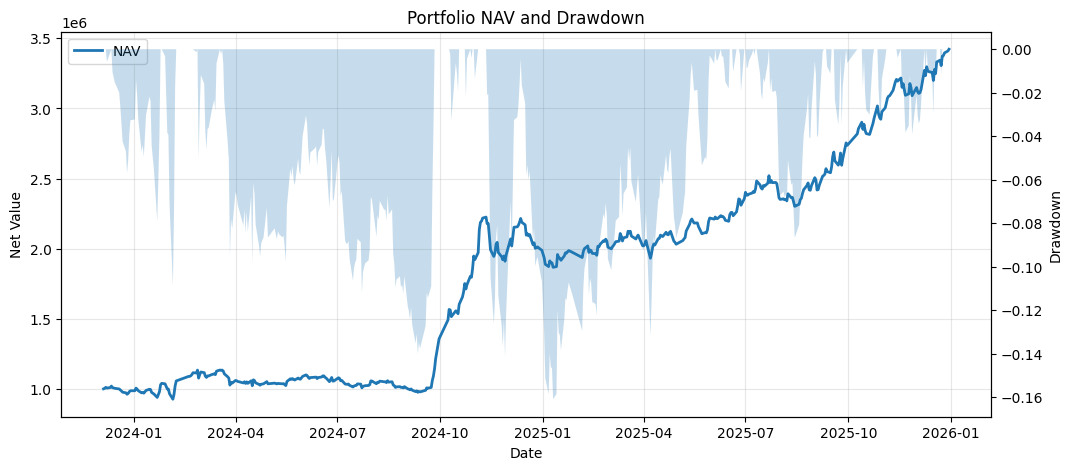

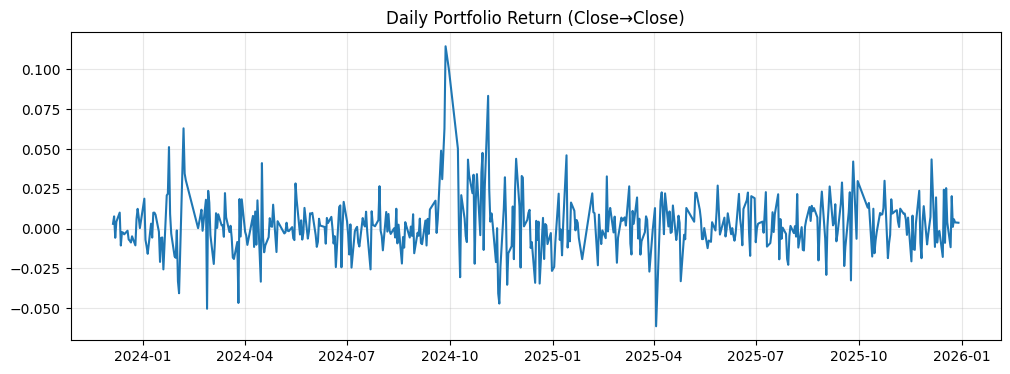

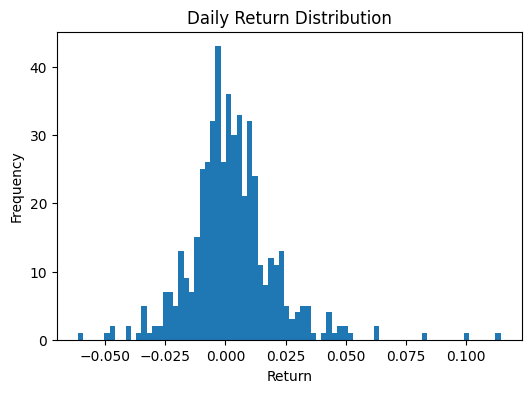

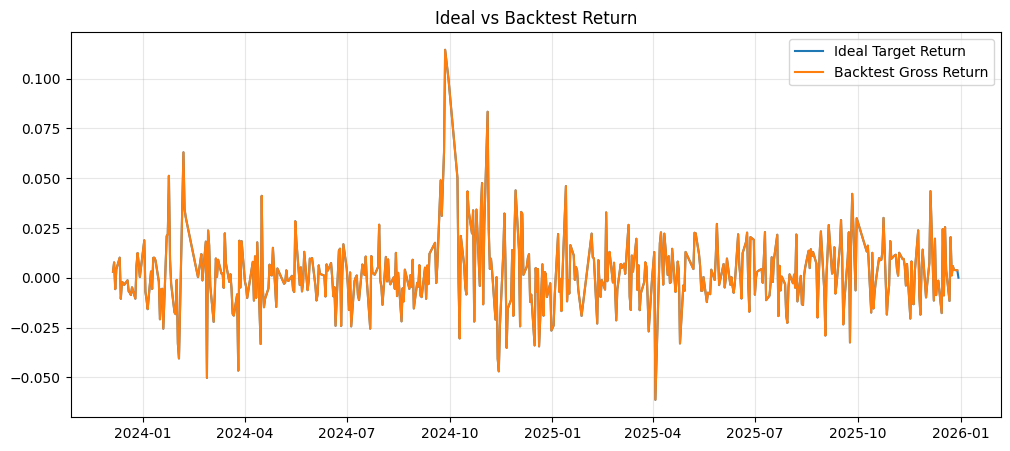

In [10]:
check_daily = plot_backtest_results(
    frame=res_zero["frame"],
    equity_curve=res_zero["equity_curve"],
    day_col="TradingDay"
)

In [11]:
# 正常交易回测
wobj = transform_signal_to_weight_topk(
    signal_mat=prep["signal_mat"],
    eligible_mat=prep["eligible_mat"],
    top_k=5,
)

res = run_close_to_close_backtest_from_weight(
    price_mat=prep["price_mat"],
    spread_mat=prep["spread_mat"],
    target_w_mat=wobj["target_w_mat"],
    signal_used_mat=wobj["signal_used_mat"],
    day_col="TradingDay",
    stock_col="SecuCode",
    init_cash=1_000_000.0,
    fee_rate=0.002,
    lot_size=None,
)

frame = res["frame"]
equity_curve = res["equity_curve"]

gross_nav = (1 + equity_curve["holding_return_gross_cc"].fillna(0)).cumprod()
net_nav   = (1 + equity_curve["holding_return_net_cc"].fillna(0)).cumprod()

gross_nav

C:\Users\16473\AppData\Local\Temp\ipykernel_9256\1531765244.py:186: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  price_t = price_mat.stack(dropna=False).rename("price_close_t").reset_index()
C:\Users\16473\AppData\Local\Temp\ipykernel_9256\1531765244.py:187: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  price_t1 = price_mat.shift(-1).stack(dropna=False).rename("price_close_t1").reset_index()
C:\Users\16473\AppData\Local\Temp\ipykernel_9256\1531765244.py:190: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pan

0      1.003022
1      1.010745
2      1.004943
3      1.009257
4      1.019447
         ...   
498    3.380223
499    3.399932
500    3.413270
501    3.425941
502    3.425941
Name: holding_return_gross_cc, Length: 503, dtype: float64

In [12]:
net_nav

0      0.996961
1      0.999636
2      0.987322
3      0.986837
4      0.992050
         ...   
498    0.288364
499    0.288347
500    0.287818
501    0.288068
502    0.288068
Name: holding_return_net_cc, Length: 503, dtype: float64

In [13]:
day_col = 'TradingDay'
paper_ret = frame.groupby(day_col)["contrib_target"].sum().sort_index()
paper_nav = (1 + paper_ret.fillna(0)).cumprod()
paper_nav

TradingDay
20231205    1.003022
20231206    1.010745
20231207    1.004952
20231208    1.009266
20231211    1.019447
              ...   
20251224    3.376639
20251225    3.396441
20251226    3.409765
20251229    3.422423
20251230    3.422423
Name: contrib_target, Length: 503, dtype: float64

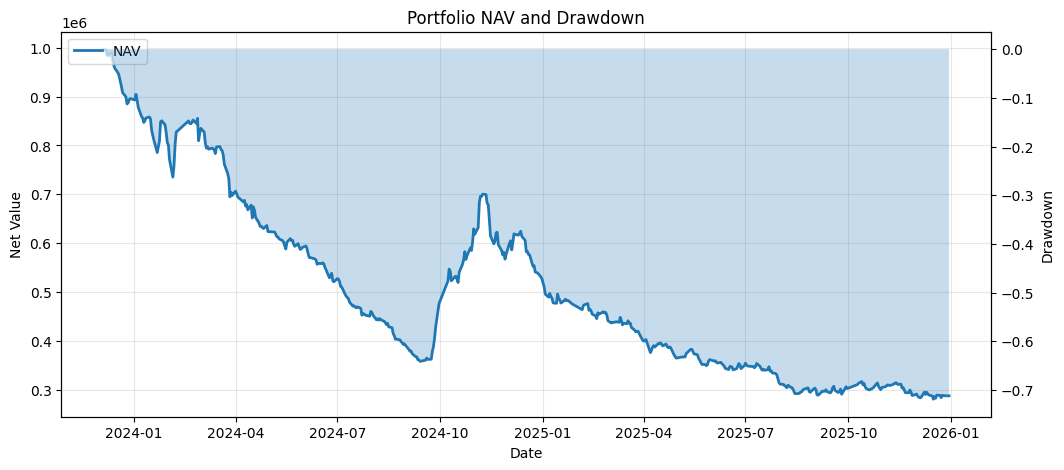

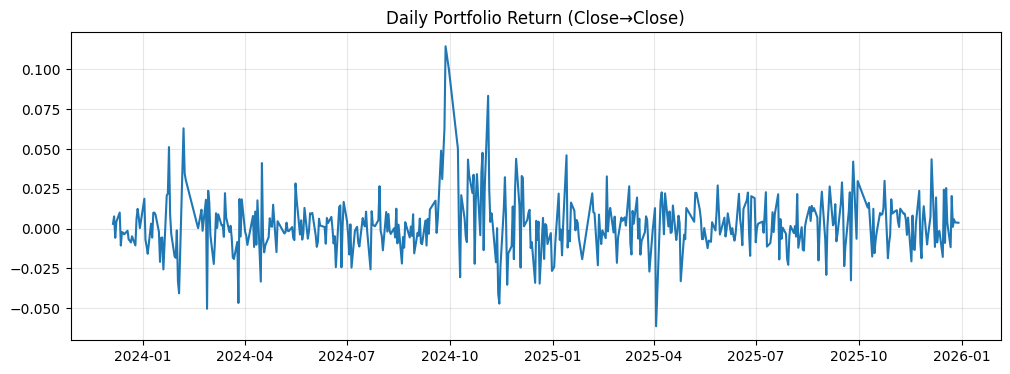

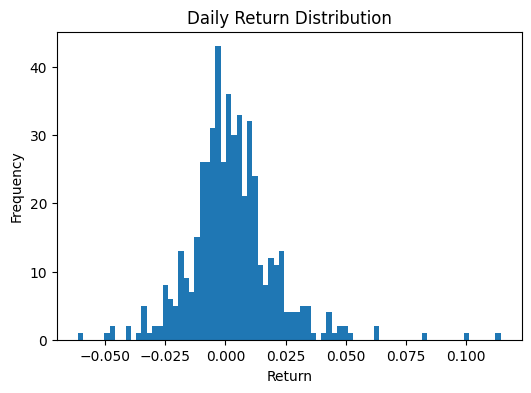

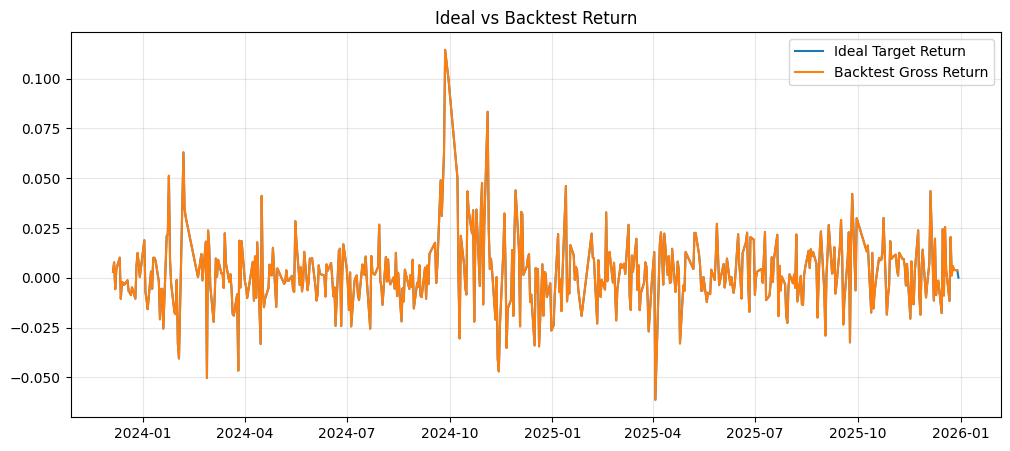

In [14]:
check_daily = plot_backtest_results(frame, equity_curve)